
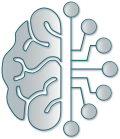

**Start at:** Wednesday 29 November 2023, 20:45:03  
**Hostname:** ip-sw-install-nico.insa-toulouse.fr (Linux)

<p style="text-align: center"><img width="800px" src="./config/svg/pyPhysChemBanner.svg" style="margin-left:auto; margin-right:auto"/></p>

In [1]:

import os
import sys

cwd0 = './config/'
sys.path.append(cwd0)

import visualID_Eng as vID
from visualID_Eng import color
vID.init(cwd0)
import tools4pyPhysChem as t4pPC

__author__ = "Franck Jolibois, LPCNO (INSA-CNRS-UT3 lab, Toulouse, France)"

# <!-- TITLE --> MOLECULAR DYNAMICS - VELOCITY VERLET ALGORITHM

## Introduction

<div class="intro">

This computer lab deal with Classical molecular dynamics. In the context of theoretical chemistry, classical molecular dynamic is a computational method that allows study the motion of atoms or molecule under the influence of a specific potential. The principle of molecular dynamic is to solve Newton’s equations of motions in order to simulate the dynamical behaviour of nuclei.
    
The principle of classical molecular dynamics is to solve Newton's equations to model the dynamic behavior of nuclei. In order to calculate the positions of atoms at a given time, it is necessary to use a "propagator". Of the many propagators available, the "Velocity-Verlet" type is among the most widely used. In this case, positions and velocities are propagated over time according to the following equations.
\begin{align}    
\mathbf{x(t+\delta t)=x(t)+v_x(t).\delta t+\frac{1}{2} \gamma(t).\delta t^2} \\    
\end{align}
    
\begin{align}   
\mathbf{v_x(t+\delta t)=v_x(t)+\frac{\gamma(t)+\gamma(t+δt)}{2}.\delta t} \\
\end{align}
    
whith $v(t)$, the velocity (first derivatives of positions with respect to time) and $\gamma (t)$, the acceleration (second derivatives of positions with respect to time).
    
To determine accelerations, we use Newton's law, which relates acceleration to force and thus to the energy gradient.
    
\begin{align}
\vec{\gamma}(t) & = \frac{\vec{F}(t)}{M} \\
\end{align}
    
    
\begin{align}
\vec{F}(t)&=-\vec{\nabla}_x{\mathbf{V(x(t))}}&= -\frac{\partial V(x(t))}{\partial x} \\
\end{align}
    
Initial conditions ($x(t=0)$ and $v(t=0)$) and a potential function are therefore required to achieve dynamics. The propagation of positions and velocities is iterative. By rewriting the "velocity verlet" equations considering t=0, the positions and velocities calculated for δt will become the positions and velocities at t=0 for the next point and so on....
For this project, we'll consider a particle of mass 1 moving on a one-dimensional model potential (the generalisation to two- or more-dimension is straitforward)

</div>



## Definition of the differents potentials

<div class="rqT" title="Directives">
    
- It is necessary to define model potentials before performing MD simulations
- These potentials and the associated forces must be defined using symbolic algebra and may need the SymPy module
</div>


<u>One-dimensional model potentials considered</u>:
    
    
**Harmonic potential**: $$ V(x)=k.(x-x_e)^2 $$


**Morse Potential**: $$V(x)=D_e.(1-e^{-\alpha(x-x_e)})^2$$


**Double_well potential**: $$ V(x)=\frac{1}{2}(f_1(x)+f_2(x))-\frac{1}{2}\sqrt{(f_1(x)-f_2(x))^2+h^2} $$

with $$ f_i(x)=k_i.(x-x_{ei})^2 + V_i $$

    



In [10]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

print("SymPy imported correctly")


SymPy imported correctly


<div class="rqT" title="Directives">
    
- Each potential can be characterized by several parameters, which need to be defined beforehand. 
</div>

In [11]:
#Define parameters for potentials:
m = 1       # mass of the particle
xe_1 = 0    # Equilibrium distance for harmonic, Morse and double well potentials
xe_2 = -2   # Equilibrium distance for double well potential only

k_1 =  2    # Force constant for harmonic and double well potentials
k_2 =  2    # Force constant for double well potential only

alpha = 0.05     # Parameter for Morse potentia
De = 2           # Prefactor for Morse potential

V_1 =  0      # Translation of potential (1) for double well potential
V_2 =  0      # Translation of potential (2) for double well potential

h = 2         # Coupling term for double well potential

<div class="exE">

- To simplify the switch between potentials, define three differents function as a function of x, one for each potential
- <b/>Forces</b> are a point of utmost importance of the algorithm. Define a function to calculate forces for a selected potential
- Display the analytic expression of the selected potential and associated forces
- Plot the selected potential as a function of the variable 'x' (You may need to use the lambdify function in the SymPy module to calculate a numerical value). 
    
</div>

V_harmonic(0) = 0.0
V_morse(0)    = 0.0
V_double(0)   = -0.12310562561766059


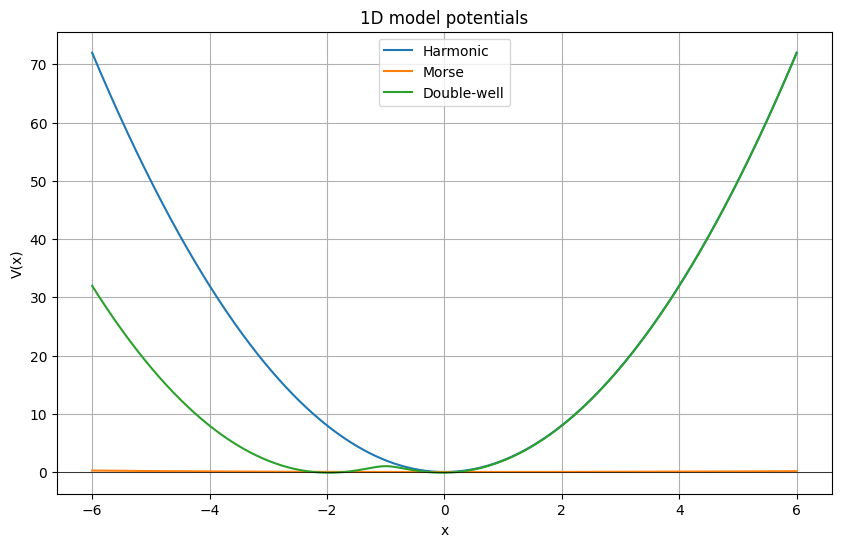

In [12]:
#  Define symbolic potentials
x = sp.symbols('x')

# Symbolic potentials
V_harmonic = k_1 * (x - xe_1)**2
V_morse    = De * (1 - sp.exp(-alpha * (x - xe_1)))**2

f1 = k_1 * (x - xe_1)**2 + V_1
f2 = k_2 * (x - xe_2)**2 + V_2
V_double = sp.Rational(1,2) * (f1 + f2) - sp.Rational(1,2) * sp.sqrt((f1 - f2)**2 + h**2)

#  Symbolic forces
F_harmonic = -sp.diff(V_harmonic, x)
F_morse    = -sp.diff(V_morse, x)
F_double   = -sp.diff(V_double, x)

# Lambdify into numeric functions
Vh_num = sp.lambdify(x, V_harmonic, "numpy")
Vm_num = sp.lambdify(x, V_morse, "numpy")
Vd_num = sp.lambdify(x, V_double, "numpy")

Fh_num = sp.lambdify(x, F_harmonic, "numpy")
Fm_num = sp.lambdify(x, F_morse, "numpy")
Fd_num = sp.lambdify(x, F_double, "numpy")

print("V_harmonic(0) =", Vh_num(0.0))
print("V_morse(0)    =", Vm_num(0.0))
print("V_double(0)   =", Vd_num(0.0))

# Plot all three potentials
x_vals = np.linspace(-6, 6, 800)

plt.figure(figsize=(10,6))
plt.plot(x_vals, Vh_num(x_vals), label="Harmonic")
plt.plot(x_vals, Vm_num(x_vals), label="Morse")
plt.plot(x_vals, Vd_num(x_vals), label="Double-well")
plt.axhline(0, color='k', linewidth=0.5)
plt.xlabel("x")
plt.ylabel("V(x)")
plt.title("1D model potentials")
plt.legend()
plt.grid(True)
plt.show()


## Velocity Verlet Algorithm

<div class="rqT" title="Directives">
    
- Several parameters must be defined to control the MD simulation:
    - step time <b/> δt</b>     
    - Total time or number of steps 
    - The initial position and initial velocity
- <b/>Total energy</b>, defined in the context of Hamiltonian mechanics, is a constant. It must be calculated for each time step in order to check that the algorithm behaves correctly. 
- You will need to use the lambdify function in the SymPy module to calculate a numerical force value for each position.  

</div>

<div class="exE">

- Define the variables that describe the parameters of the MD simulation (initial time will be set to 0)
- Use a loop to implement the velocity verlet algorithm
    - Defining functions for updating positions and speeds can be useful but is not mandatory
- For each step (including the initial step), record in separate tables (or in a single file)
    - Time
    - Position
    - Velocity
    - Energy (i.e value of the potential)
    - Total energy
    
    
</div>

   time         x         v        PE        KE   E_total
0  0.00 -0.200000  0.800000  0.000202  0.320000  0.320202
1  0.01 -0.192000  0.800020  0.000186  0.320016  0.320202
2  0.02 -0.184000  0.800039  0.000171  0.320031  0.320202
3  0.03 -0.175999  0.800057  0.000156  0.320046  0.320202
4  0.04 -0.167998  0.800075  0.000142  0.320060  0.320202
5  0.05 -0.159998  0.800091  0.000129  0.320073  0.320202
6  0.06 -0.151997  0.800107  0.000116  0.320086  0.320202
7  0.07 -0.143995  0.800122  0.000104  0.320098  0.320202
8  0.08 -0.135994  0.800136  0.000093  0.320109  0.320202
9  0.09 -0.127993  0.800149  0.000082  0.320120  0.320202
       time         x         v        PE        KE   E_total
4996  49.96 -4.737067 -0.595569  0.142851  0.177351  0.320202
4997  49.97 -4.743020 -0.594891  0.143254  0.176948  0.320202
4998  49.98 -4.748965 -0.594212  0.143658  0.176544  0.320202
4999  49.99 -4.754904 -0.593532  0.144062  0.176140  0.320202
5000  50.00 -4.760836 -0.592850  0.144466  0.175736 

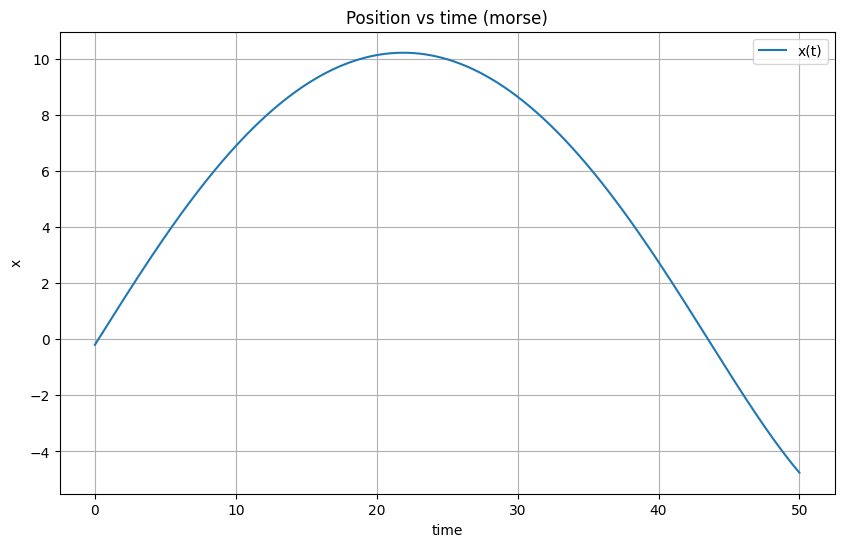

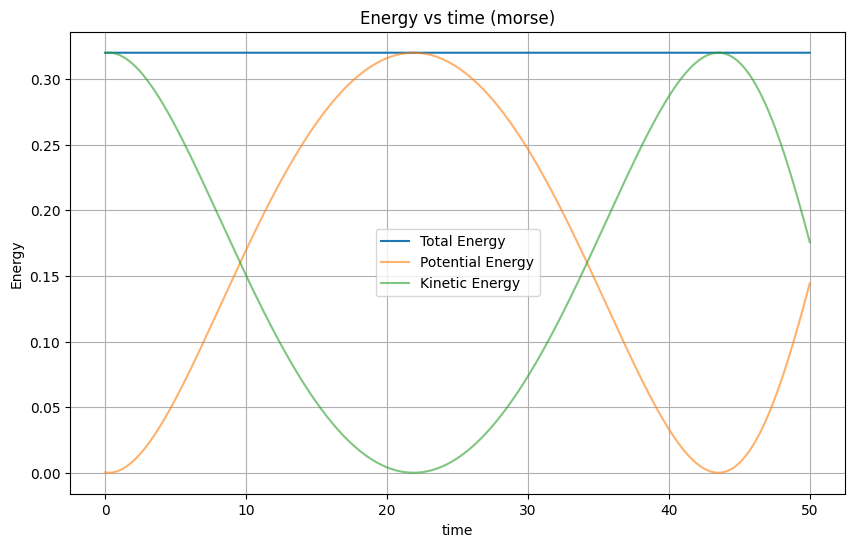

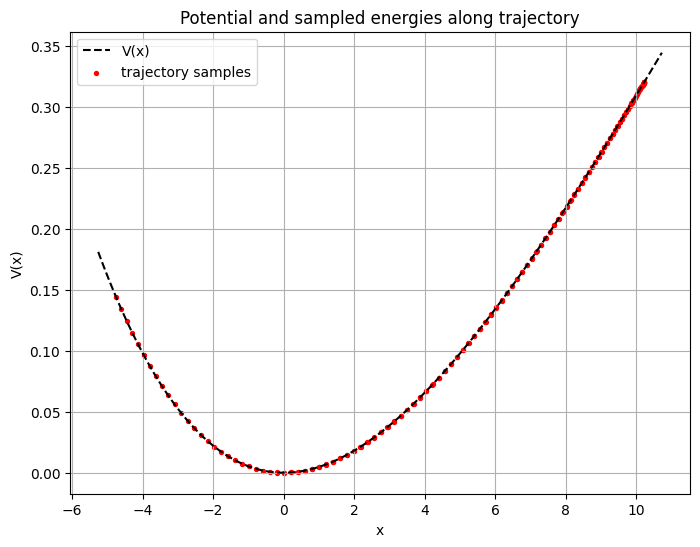

In [14]:

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math


# Symbolic potentials and forces

x = sp.symbols('x', real=True)

# Parameters for potentials
k_1 = 2
k_2 = 2
xe_1 = 0
xe_2 = -2
alpha = 0.05
De = 2
V_1 = 0
V_2 = 0
h = 2

# Symbolic potentials
V_harmonic = k_1 * (x - xe_1)**2
V_morse    = De * (1 - sp.exp(-alpha * (x - xe_1)))**2
f1 = k_1 * (x - xe_1)**2 + V_1
f2 = k_2 * (x - xe_2)**2 + V_2
V_double = sp.Rational(1,2) * (f1 + f2) - sp.Rational(1,2) * sp.sqrt((f1 - f2)**2 + h**2)

# Forces: F(x) = -dV/dx
F_harmonic = -sp.diff(V_harmonic, x)
F_morse    = -sp.diff(V_morse, x)
F_double   = -sp.diff(V_double, x)

# Lambdify to get fast numeric functions that accept numpy arrays
Vh_num = sp.lambdify(x, V_harmonic, "numpy")
Vm_num = sp.lambdify(x, V_morse, "numpy")
Vd_num = sp.lambdify(x, V_double, "numpy")

Fh_num = sp.lambdify(x, F_harmonic, "numpy")
Fm_num = sp.lambdify(x, F_morse, "numpy")
Fd_num = sp.lambdify(x, F_double, "numpy")


# 2) Select potential for the MD run

# Choose 'harmonic', 'morse' or 'double'
potential_choice = 'morse'  

if potential_choice == 'harmonic':
    V_func = Vh_num
    F_func = Fh_num
elif potential_choice == 'morse':
    V_func = Vm_num
    F_func = Fm_num
elif potential_choice == 'double':
    V_func = Vd_num
    F_func = Fd_num
else:
    raise ValueError("Unknown potential_choice. Use 'harmonic', 'morse' or 'double'.")


#  MD parameters 

m = 1.0                 # mass
dt = 0.01               # timestep
n_steps = 5000          # number of MD steps
t0 = 0.0                # initial time

# Initial conditions 
x0 = -0.2               # initial position
v0 = 0.8                # initial velocity


# Prepare arrays to store trajectory

times = np.zeros(n_steps + 1)
xs = np.zeros(n_steps + 1)
vs = np.zeros(n_steps + 1)
pes = np.zeros(n_steps + 1)   # potential energies
kes = np.zeros(n_steps + 1)   # kinetic energies
tes = np.zeros(n_steps + 1)   # total energies

# initialize
times[0] = t0
xs[0] = x0
vs[0] = v0
pes[0] = float(V_func(x0))
kes[0] = 0.5 * m * v0**2
tes[0] = pes[0] + kes[0]

# compute initial acceleration gamma(0) = F(x0)/m
gamma = float(F_func(x0)) / m


# Velocity-Verlet integration loop

for i in range(n_steps):
    # 1) Update position: x(t+dt) = x(t) + v(t)*dt + 0.5 * gamma(t) * dt^2
    x_new = xs[i] + vs[i]*dt + 0.5 * gamma * dt**2

# Evaluate force (and acceleration) at new position
    F_new = float(F_func(x_new))
    gamma_new = F_new / m
    

# Update velocity: v(t+dt) = v(t) + 0.5*(gamma(t) + gamma(t+dt)) * dt
    v_new = vs[i] + 0.5 * (gamma + gamma_new) * dt

# Advance time
    t_new = times[i] + dt

# Store new values
    times[i+1] = t_new
    xs[i+1] = x_new
    vs[i+1] = v_new
    pes[i+1] = float(V_func(x_new))
    kes[i+1] = 0.5 * m * v_new**2
    tes[i+1] = pes[i+1] + kes[i+1]

# Prepare for next iteration
    gamma = gamma_new


# Pack into a pandas DataFrame and show the first rows

df = pd.DataFrame({
    'time': times,
    'x': xs,
    'v': vs,
    'PE': pes,
    'KE': kes,
    'E_total': tes
})

print(df.head(10))   # show first 10 rows
print(df.tail(5))    # show last 5 rows

# Save to CSV 
csv_filename = f"md_trajectory_{potential_choice}.csv"
df.to_csv(csv_filename, index=False)
print(f"Trajectory saved to: {csv_filename}")


# Simple post-processing plots

plt.figure(figsize=(10,6))
plt.plot(times, xs, label='x(t)')
plt.xlabel('time')
plt.ylabel('x')
plt.title(f'Position vs time ({potential_choice})')
plt.grid(True)
plt.legend()

plt.figure(figsize=(10,6))
plt.plot(times, tes, label='Total Energy')
plt.plot(times, pes, label='Potential Energy', alpha=0.6)
plt.plot(times, kes, label='Kinetic Energy', alpha=0.6)
plt.xlabel('time')
plt.ylabel('Energy')
plt.title(f'Energy vs time ({potential_choice})')
plt.legend()
plt.grid(True)

plt.figure(figsize=(8,6))

# potential curve and trajectory points
x_plot = np.linspace(min(xs)-0.5, max(xs)+0.5, 400)
plt.plot(x_plot, V_func(x_plot), 'k--', label='V(x)')
plt.scatter(xs[::max(1, n_steps//200)], pes[::max(1, n_steps//200)], s=8, c='r', label='trajectory samples')
plt.xlabel('x')
plt.ylabel('V(x)')
plt.title('Potential and sampled energies along trajectory')
plt.legend()
plt.grid(True)

plt.show()



## Post processing

<div class="rqT" title="Directives">
    
- The advantage of MD simulation is that several parameters are stored (in tables or files) and can be used for post-processing
    
    - To check the validity of the algorithm
    - To calculate mean structural or spectroscopic properties

</div>

<div class="exE">

- To check the validity of the algorithm
    - Plot the stored potentials as a function of stored positions 
    - Plot the stored positions or velocities as a function of time
    - Plot the variation in total energy (as a percentage) as a function of time
- To calculate mean structural or spectroscopic properties
    - Calculate the mean value of the position
    
    
</div>

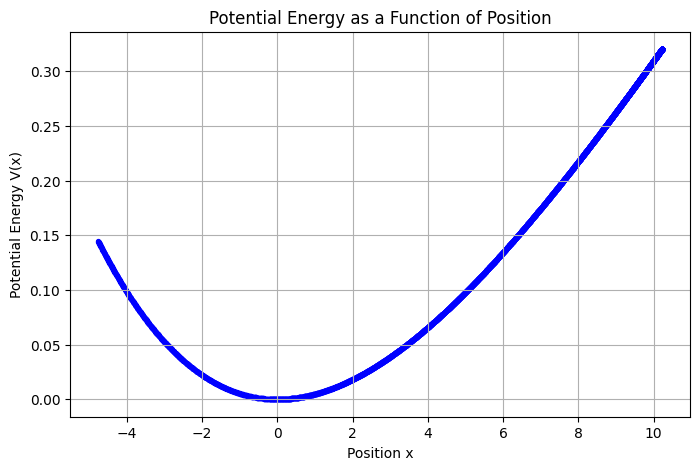

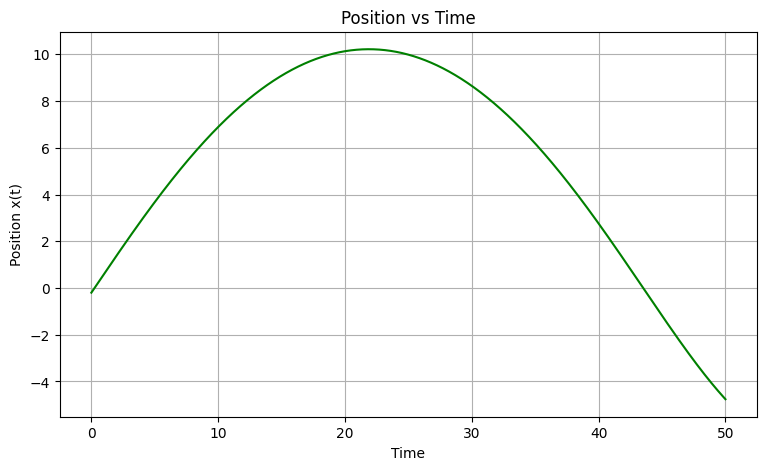

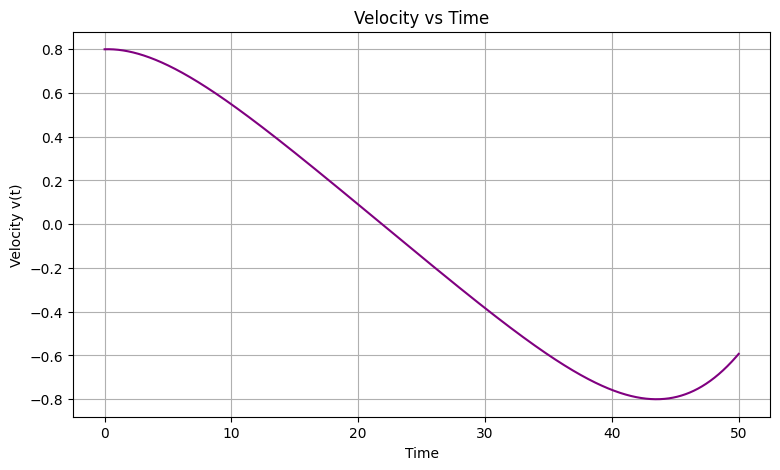

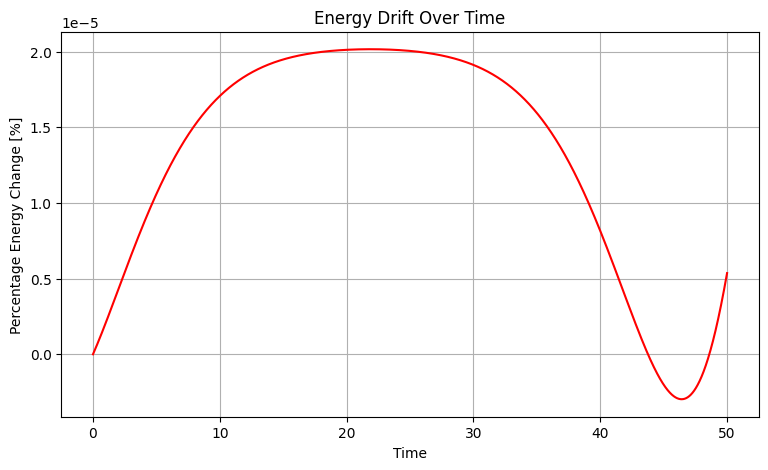

Mean position <x> = 5.427787357490617


In [15]:


import matplotlib.pyplot as plt
import numpy as np

#  Plot Potential Energy vs Position
plt.figure(figsize=(8,5))
plt.scatter(df["x"], df["PE"], s=8, color="blue")
plt.xlabel("Position x")
plt.ylabel("Potential Energy V(x)")
plt.title("Potential Energy as a Function of Position")
plt.grid(True)
plt.show()


# Plot Position vs Time
plt.figure(figsize=(9,5))
plt.plot(df["time"], df["x"], color="green")
plt.xlabel("Time")
plt.ylabel("Position x(t)")
plt.title("Position vs Time")
plt.grid(True)
plt.show()


# Plot Velocity vs Time
plt.figure(figsize=(9,5))
plt.plot(df["time"], df["v"], color="purple")
plt.xlabel("Time")
plt.ylabel("Velocity v(t)")
plt.title("Velocity vs Time")
plt.grid(True)
plt.show()


# Percentage variation of total energy
E0 = df["E_total"].iloc[0]          # initial total energy
percent_variation = 100*(df["E_total"] - E0)/E0

plt.figure(figsize=(9,5))
plt.plot(df["time"], percent_variation, color="red")
plt.xlabel("Time")
plt.ylabel("Percentage Energy Change [%]")
plt.title("Energy Drift Over Time")
plt.grid(True)
plt.show()


# Compute mean structural properties
mean_position = df["x"].mean()
print("Mean position <x> =", mean_position)



## OPTIONNAL :Beyond the potential of one dimension - 2D potentials

<div class="rqT" title="Directives">
    
- A two-dimensional potential can simply be created by adding a one-dimensional potential along x and another along y, as well as any coupling function between x and y.
    
 $$ V(x,y)=V_1(x)+V_2(y)+f(x,y) $$
    
where $𝑉_1 (𝑥)$ and $𝑉_2 (𝑦)$ can be one of the previous potential and with, for example, $𝑓(𝑥,𝑦)=𝑥.𝑦$
    
Using a double-well potential for $𝑉_1 (𝑥)$ and $𝑉_2 (𝑦)$ and the coupling function define just before will creat a four-well potential.


- Another way to implement a two-dimensional potential is to use the so-called Muller-Brown potential:
   $$ V(x,y)=\sum_{i=1}^4 A_i.exp[a_i(x-x^0_i)^2+b_i(x-x^0_i)(y-y^0_i)+c_i(y-y^0_i)^2] $$
    
with

A = (−200, −100, −170, 15)
    
a = (−1, −1, −6.5, 0.7) ; b = (0, 0, 11, 0.6) ; c = (−10, −10, −6.5, 0.7)
    
$x^0$ = (1, 0, −0.5, −1) ; $y^0$ = (0, 0.5, 1.5, 1)
     
</div>

<div class="rqT" title="Directives">
    
- For the Velocity-Verlet algorithm, you will need to calculate new positions (new $x$ and new $y$) and speeds (new $v_x$ and new $v_y$) using the formula given at the beginning:

For $x$:
    
\begin{align}    
\mathbf{x(t+\delta t)=x(t)+v_x(t).\delta t-\frac{1}{2M}\frac{\partial V(x(t),y(t))}{\partial x}.\delta t^2} \\    
\end{align}
    
\begin{align}   
\mathbf{v_x(t+\delta t)=v_x(t)-\frac{1}{2M}[\frac{\partial V(x(t),y(t))}{\partial x}+\frac{\partial V(x(t+\delta t),y(t+\delta t))}{\partial x}].\delta t} \\
\end{align}
    
For $y$:
    
\begin{align}    
\mathbf{y(t+\delta t)=y(t)+v_y(t).\delta t-\frac{1}{2M}\frac{\partial V(x(t),y(t))}{\partial y}.\delta t^2} \\    
\end{align}
    
\begin{align}   
\mathbf{v_y(t+\delta t)=v_y(t)-\frac{1}{2M}[\frac{\partial V(x(t),y(t))}{\partial y}+\frac{\partial V(x(t+\delta t),y(t+\delta t))}{\partial y}].\delta t} \\
\end{align}
        
</div>

<div class="exE">

- You need to answer the same questions as for the 1D potential problem
    
    
</div>

Simulation finished. Trajectory saved to: md2d_morse_traj.csv
   time         x         y        vx        vy        PE        KE   E_total
0  0.00  0.500000 -0.200000  0.600000 -0.400000  0.001421  0.260000  0.261421
1  0.01  0.506000 -0.204000  0.599952 -0.399979  0.001458  0.259963  0.261421
2  0.02  0.511999 -0.208000  0.599903 -0.399959  0.001496  0.259925  0.261421
3  0.03  0.517998 -0.211999  0.599853 -0.399937  0.001534  0.259887  0.261421
4  0.04  0.523996 -0.215998  0.599803 -0.399915  0.001573  0.259848  0.261421
       time         x         y        vx        vy        PE        KE  \
3996  39.96 -0.860882  3.976686 -0.595567  0.174216  0.068896  0.192526   
3997  39.97 -0.866838  3.978427 -0.595475  0.173920  0.069002  0.192419   
3998  39.98 -0.872792  3.980164 -0.595382  0.173624  0.069109  0.192313   
3999  39.99 -0.878745  3.981899 -0.595288  0.173328  0.069216  0.192206   
4000  40.00 -0.884698  3.983631 -0.595194  0.173032  0.069323  0.192098   

       E_total  
39

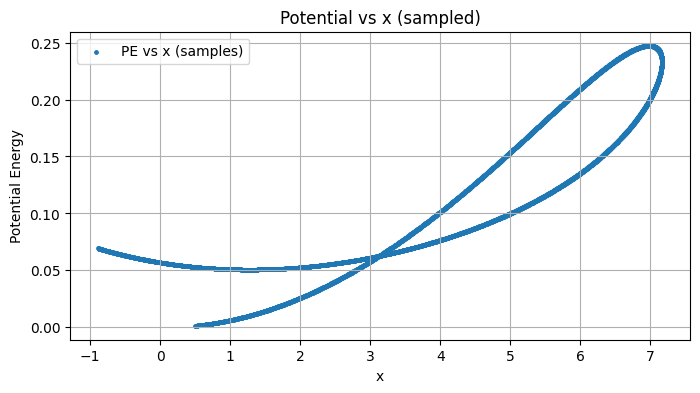

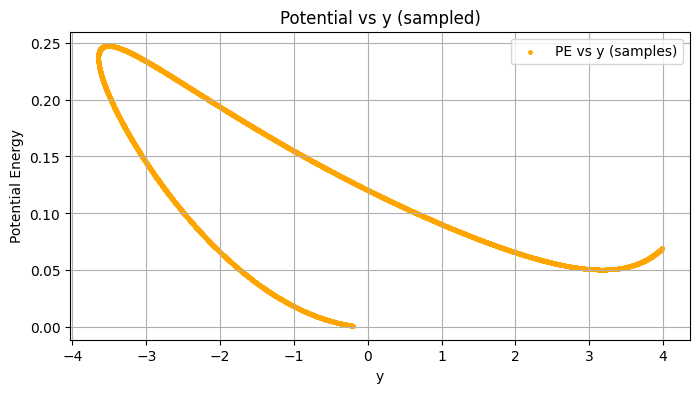

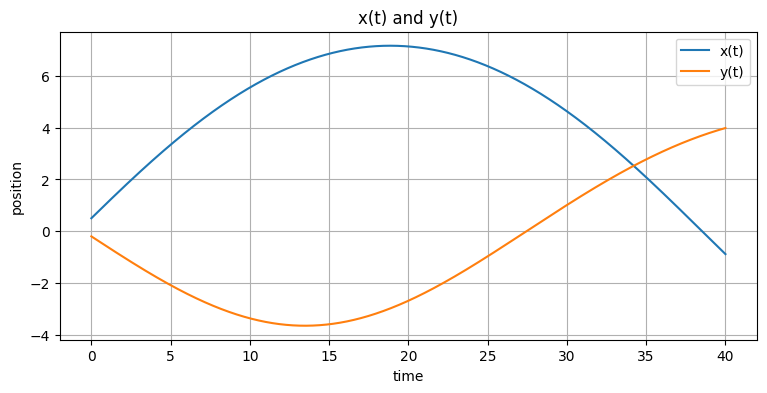

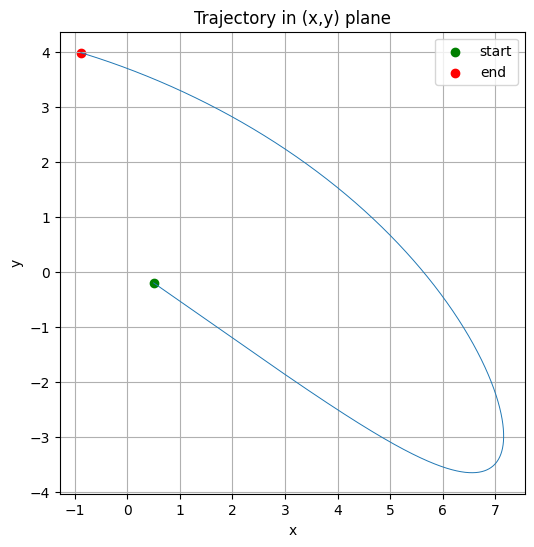

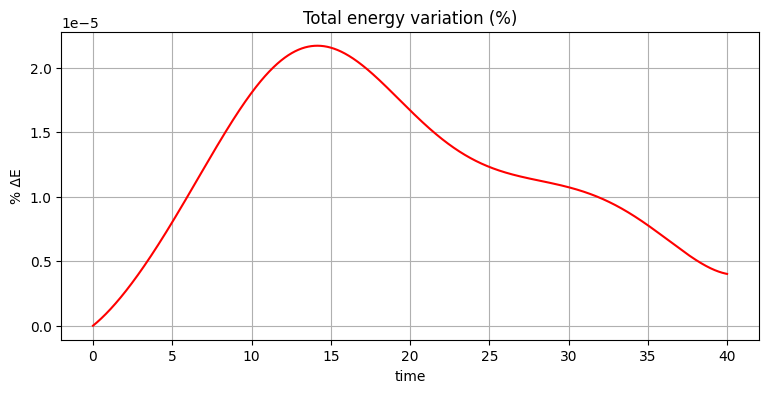

In [2]:

# 2D Velocity-Verlet MD


import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math

# Symbolic variables and potential parameters

x, y = sp.symbols('x y', real=True)

# parameters
k_1 = 2
k_2 = 2
xe_1 = 0
xe_2 = -2
alpha = 0.05
De = 2
V_1 = 0
V_2 = 0
h = 2

#  Define 1D potentials (for x and y)


# Harmonic
Vx_harm = k_1 * (x - xe_1)**2
Vy_harm = k_1 * (y - xe_1)**2

# Morse
Vx_morse = De * (1 - sp.exp(-alpha * (x - xe_1)))**2
Vy_morse = De * (1 - sp.exp(-alpha * (y - xe_1)))**2

# Double-well
f1x = k_1 * (x - xe_1)**2 + V_1
f2x = k_2 * (x - xe_2)**2 + V_2
Vx_double = sp.Rational(1,2) * (f1x + f2x) - sp.Rational(1,2) * sp.sqrt((f1x - f2x)**2 + h**2)

f1y = k_1 * (y - xe_1)**2 + V_1
f2y = k_2 * (y - xe_2)**2 + V_2
Vy_double = sp.Rational(1,2) * (f1y + f2y) - sp.Rational(1,2) * sp.sqrt((f1y - f2y)**2 + h**2)


# Select potential type for 2D run (one of 'harmonic','morse','double')

potential_choice = 'morse'   # 

if potential_choice == 'harmonic':
    Vx_sym = Vx_harm
    Vy_sym = Vy_harm
elif potential_choice == 'morse':
    Vx_sym = Vx_morse
    Vy_sym = Vy_morse
elif potential_choice == 'double':
    Vx_sym = Vx_double
    Vy_sym = Vy_double
else:
    raise ValueError("Invalid potential_choice. Use 'harmonic', 'morse' or 'double'.")


# Symbolic forces and lambdify numeric functions

Fx_sym = -sp.diff(Vx_sym, x)
Fy_sym = -sp.diff(Vy_sym, y)

Vx_num = sp.lambdify(x, Vx_sym, 'numpy')
Vy_num = sp.lambdify(y, Vy_sym, 'numpy')
Fx_num = sp.lambdify(x, Fx_sym, 'numpy')
Fy_num = sp.lambdify(y, Fy_sym, 'numpy')

# Quick numeric check (optional prints)
#print("Vx(0)=", Vx_num(0.0), "Vy(0)=", Vy_num(0.0))


# MD simulation parameters and initial conditions

m = 1.0                 # mass
dt = 0.01               # timestep
n_steps = 4000          # number of MD steps

# initial conditions
x0 = 0.5
y0 = -0.2
vx0 = 0.6
vy0 = -0.4
t0 = 0.0


# Allocate storage arrays

time = np.zeros(n_steps + 1)
xs = np.zeros(n_steps + 1)
ys = np.zeros(n_steps + 1)
vxs = np.zeros(n_steps + 1)
vys = np.zeros(n_steps + 1)
PE = np.zeros(n_steps + 1)
KE = np.zeros(n_steps + 1)
Etot = np.zeros(n_steps + 1)

# initial assignments
time[0] = t0
xs[0] = x0
ys[0] = y0
vxs[0] = vx0
vys[0] = vy0
PE[0] = float(Vx_num(x0) + Vy_num(y0))
KE[0] = 0.5 * m * (vx0**2 + vy0**2)
Etot[0] = PE[0] + KE[0]

ax = float(Fx_num(x0)) / m
ay = float(Fy_num(y0)) / m


# 2D Velocity-Verlet integration loop

for i in range(n_steps):
    # update positions
    x_new = xs[i] + vxs[i]*dt + 0.5 * ax * dt**2
    y_new = ys[i] + vys[i]*dt + 0.5 * ay * dt**2

# compute new forces and accelerations
    Fx_new = float(Fx_num(x_new))
    Fy_new = float(Fy_num(y_new))
    ax_new = Fx_new / m
    ay_new = Fy_new / m

# update velocities
    vx_new = vxs[i] + 0.5 * (ax + ax_new) * dt
    vy_new = vys[i] + 0.5 * (ay + ay_new) * dt

# advance time
    t_new = time[i] + dt

# store
    time[i+1] = t_new
    xs[i+1] = x_new
    ys[i+1] = y_new
    vxs[i+1] = vx_new
    vys[i+1] = vy_new
    PE[i+1] = float(Vx_num(x_new) + Vy_num(y_new))
    KE[i+1] = 0.5 * m * (vx_new**2 + vy_new**2)
    Etot[i+1] = PE[i+1] + KE[i+1]
    
# prepare for next step
    ax = ax_new
    ay = ay_new


# Pack results into DataFrame and save CSV

df2d = pd.DataFrame({
    'time': time,
    'x': xs,
    'y': ys,
    'vx': vxs,
    'vy': vys,
    'PE': PE,
    'KE': KE,
    'E_total': Etot
})

csv_name = f"md2d_{potential_choice}_traj.csv"
df2d.to_csv(csv_name, index=False)

print("Simulation finished. Trajectory saved to:", csv_name)
print(df2d.head())
print(df2d.tail())


# Post-processing plots

# Plot stored potentials as a function of stored positions (PE vs x and PE vs y)
plt.figure(figsize=(8,4))
plt.scatter(xs, PE, s=6, label='PE vs x (samples)')
plt.xlabel('x'); plt.ylabel('Potential Energy'); plt.title('Potential vs x (sampled)')
plt.grid(True); plt.legend()

plt.figure(figsize=(8,4))
plt.scatter(ys, PE, s=6, label='PE vs y (samples)', color='orange')
plt.xlabel('y'); plt.ylabel('Potential Energy'); plt.title('Potential vs y (sampled)')
plt.grid(True); plt.legend()

# Plot x(t) and y(t)
plt.figure(figsize=(9,4))
plt.plot(time, xs, label='x(t)')
plt.plot(time, ys, label='y(t)')
plt.xlabel('time'); plt.ylabel('position'); plt.title('x(t) and y(t)')
plt.legend(); plt.grid(True)

# 2D trajectory (x vs y)
plt.figure(figsize=(6,6))
plt.plot(xs, ys, lw=0.7)
plt.scatter(xs[0], ys[0], color='green', label='start')
plt.scatter(xs[-1], ys[-1], color='red', label='end')
plt.xlabel('x'); plt.ylabel('y'); plt.title('Trajectory in (x,y) plane')
plt.legend(); plt.grid(True)

# Plot  variation in total energy as a percentage
E0 = Etot[0]
percent_variation = 100.0 * (Etot - E0) / E0
plt.figure(figsize=(9,4))
plt.plot(time, percent_variation, color='red')
plt.xlabel('time'); plt.ylabel('% ΔE'); plt.title('Total energy variation (%)')
plt.grid(True)

# Print mean structural properties
mean_x = xs.mean()
mean_y = ys.mean()
print(f"Mean position <x> = {mean_x:.6f}")
print(f"Mean position <y> = {mean_y:.6f}")

plt.show()



# End

In [33]:
vID.end(cwd0)

**End at:** Thursday 05 October 2023, 11:05:27  
**Duration:** 01:47:26 770ms

<p style="text-align: center"><img width="800px" src="./config/svg/logoEnd.svg" style="margin-left:auto; margin-right:auto"/></p>